In [1]:
import jax
import jax.numpy as jnp

from scoresbibm.src.utils.data_utils import load_model
from scoresbibm.src.tasks.all_conditional_tasks import TwoMoonsAllConditionalTask

import matplotlib.pyplot as plt

/mnt/qb/work/macke/mgloeckler90/miniconda3/envs/probjax/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
model = load_model("../results/benchmark/",47)

In [5]:
# def score_fn(params ,t ,x ,node_id ,condition_mask ,edge_mask=None):
#     # Zero out condition_mask
#     condition_mask = jnp.zeros_like(condition_mask)
#     return model.model_fn(params,t,x,node_id,condition_mask,edge_mask)


# Repaint method
def score_fn(params ,t ,x ,node_id ,condition_mask ,edge_mask=None):
    # Zero out condition_mask
    condition_mask = jnp.zeros_like(condition_mask)
    return model.model_fn(params,t,x,node_id,condition_mask,edge_mask)

In [6]:
#model.set_default_score_fn(score_fn)

In [7]:
task = TwoMoonsAllConditionalTask()
reference_sampler = task.get_reference_sampler()
joint_sampler = task.get_joint_sampler()

In [28]:
joint_sample = joint_sampler(jax.random.PRNGKey(0))
condition_mask = jnp.array([False, False, True, False])
x_o = jnp.concatenate([joint_sample[task.var_names[i]] for i in range(4) if condition_mask[i]])

In [29]:
samples = model.sample(10000, x_o= x_o,condition_mask=condition_mask, rng=jax.random.PRNGKey(0))

In [30]:
samples_ref = reference_sampler.sample(10000, x_o= x_o,condition_mask=condition_mask,rng=jax.random.PRNGKey(0))

In [13]:
from sbi.analysis import pairplot
import numpy as np

(<Figure size 1000x1000 with 9 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>]], dtype=object))

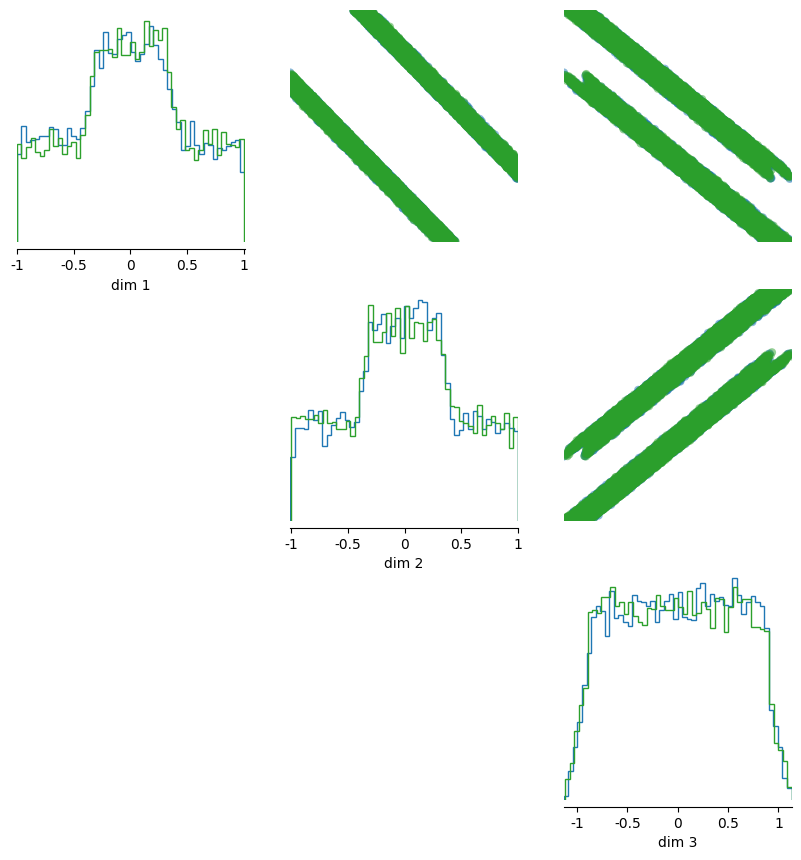

In [32]:
pairplot([np.array(samples),np.array(samples_ref)], upper="scatter")

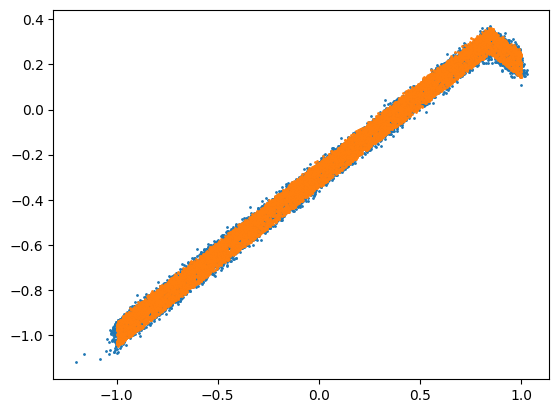

In [58]:
plt.scatter(samples[:,0],samples[:,1], s=1.)
plt.scatter(samples_ref[:,0],samples_ref[:,1], s=1.)